## eGRID Emissions Final Project — EPA GHGRP 2023

Baseline modeling pipeline for EPA Greenhouse Gas Reporting Program (GHGRP) 2023  
Facility-Level CO₂ Emissions Prediction.

**Pipeline stages:**
1. Linear Regression          — interpretable baseline
2. 1-Hidden-Layer ReLU MLP    — minimal neural network baseline
3. Deep MLP (3 layers, BN, Dropout) — bridge to full deep learning

**Dataset:** EPA GHGRP 2023, sheet `Direct Point Emitters`  
**Target:** `CO2 emissions (non-biogenic)` — metric tons CO₂ per facility per year  


**Author:** Michael Paul

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [4]:
# ── Config ─────────────────────────────────────────────────────────────────────
GHGRP_PATH  = "/content/EPA GHGRP 2023.xlsx"   # update path if needed
SHEET       = "Direct Point Emitters"
HEADER_ROW  = 3                                 # GHGRP data starts on row 4 (0-indexed: 3)
TARGET      = "CO2 emissions (non-biogenic) "   # metric tons CO2 — note trailing space in col name
TARGET_MAX  = 20_000_000                        # cap extreme outliers (max observed ~16.5M)

# ── TOGGLE THIS to switch between experiments ──────────────────────────────────
# Options:
#   SECTOR_FILTER = "Power Plants"   → train on power plants only  (~1,290 rows)
#   SECTOR_FILTER = None             → train on all facilities      (~6,470 rows)
SECTOR_FILTER = None
# ──────────────────────────────────────────────────────────────────────────────

RANDOM_SEED  = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.20
BATCH_SIZE   = 256
EPOCHS_SMALL = 50
EPOCHS_DEEP  = 100
LR           = 1e-3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

experiment_label = SECTOR_FILTER if SECTOR_FILTER else "All Sectors"
print(f"Experiment : {experiment_label}")

Experiment : All Sectors


In [5]:
# ── 1. Load & Inspect Data ─────────────────────────────────────────────────────
print("=" * 65)
print(f"STEP 1 — Load GHGRP 2023 | filter: {experiment_label}")
print("=" * 65)

df_raw = pd.read_excel(GHGRP_PATH, sheet_name=SHEET, header=HEADER_ROW)
print(f"Raw shape   : {df_raw.shape}")
print(f"\nSector distribution:")
print(df_raw["Industry Type (sectors)"].value_counts().head(10).to_string())

STEP 1 — Load GHGRP 2023 | filter: All Sectors
Raw shape   : (6470, 66)

Sector distribution:
Industry Type (sectors)
Power Plants                                                                       1290
Waste                                                                              1196
Petroleum and Natural Gas Systems                                                  1172
Other                                                                              1064
Minerals                                                                            374
Chemicals                                                                           341
Metals                                                                              278
Pulp and Paper                                                                      119
Other,Waste                                                                         110
Natural Gas and Natural Gas Liquids Suppliers,Petroleum and Natural Gas Systems      88


In [6]:
# ── 2. Sector Filter ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 2 — Apply sector filter")
print("=" * 65)

if SECTOR_FILTER is not None:
    df_filtered = df_raw[
        df_raw["Industry Type (sectors)"] == SECTOR_FILTER
    ].copy()
    print(f"Filtered to '{SECTOR_FILTER}': {len(df_filtered)} rows")
else:
    df_filtered = df_raw.copy()
    print(f"No filter applied — using all {len(df_filtered)} facilities")

# Drop rows missing the target
df_filtered[TARGET] = pd.to_numeric(df_filtered[TARGET], errors="coerce")
before = len(df_filtered)
df_filtered = df_filtered[
    df_filtered[TARGET].between(1, TARGET_MAX)
]
print(f"After target filter (1 – {TARGET_MAX:,} metric tons): "
      f"{before} → {len(df_filtered)} rows "
      f"({before - len(df_filtered)} removed)")


STEP 2 — Apply sector filter
No filter applied — using all 6470 facilities
After target filter (1 – 20,000,000 metric tons): 6470 → 5755 rows (715 removed)


In [7]:
# ── 3. Feature Selection ───────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 3 — Feature selection")
print("=" * 65)

# Categorical features — will be label-encoded
# Note: if SECTOR_FILTER is set, drop 'Industry Type (sectors)' since it's constant
cat_features = [
    "State",
    "Industry Type (subparts)",
]
if SECTOR_FILTER is None:
    # Only meaningful as a feature when multiple sectors are present
    cat_features.append("Industry Type (sectors)")

# Continuous features
continuous_features = [
    "Latitude",
    "Longitude",
    "Primary NAICS Code",
]

# Individual GHG component columns — encode fuel type / combustion process
# without directly leaking the CO2 target
ghg_features = [
    "Methane (CH4) emissions ",
    "Nitrous Oxide (N2O) emissions ",
    "HFC emissions",
    "PFC emissions",
    "SF6 emissions ",
    "Other GHGs (metric tons CO2e)",
    "Biogenic CO2 emissions (metric tons)",
]

# Process/subpart emission columns — sparse but informative
# Will receive log1p transform to handle zero-heavy distributions
process_features = [
    "Stationary Combustion",
    "Electricity Generation",
    "Ammonia Manufacturing",
    "Cement Production",
    "Hydrogen Production",
    "Iron and Steel Production",
    "Lime Production",
    "Nitric Acid Production",
    "Petroleum Refining",
    "Pulp and Paper Manufacturing",
    "Municipal Landfills",
    "Industrial Wastewater Treatment",
    "Industrial Waste Landfills",
    "Petroleum and Natural Gas Systems – Processing",
    "Petroleum and Natural Gas Systems – Transmission/Compression",
]

all_features = cat_features + continuous_features + ghg_features + process_features

# Verify columns exist
existing = set(df_filtered.columns)
missing  = [c for c in all_features if c not in existing]
if missing:
    print(f"WARNING — columns not found: {missing}")
    all_features = [c for c in all_features if c in existing]
    cat_features        = [c for c in cat_features        if c in existing]
    continuous_features = [c for c in continuous_features if c in existing]
    ghg_features        = [c for c in ghg_features        if c in existing]
    process_features    = [c for c in process_features    if c in existing]
else:
    print("All feature columns verified OK.")

print(f"\nTotal features : {len(all_features)}")
print(f"  Categorical  : {len(cat_features)}")
print(f"  Continuous   : {len(continuous_features)}")
print(f"  GHG mix      : {len(ghg_features)}")
print(f"  Process/subpart : {len(process_features)}")


STEP 3 — Feature selection
All feature columns verified OK.

Total features : 28
  Categorical  : 3
  Continuous   : 3
  GHG mix      : 7
  Process/subpart : 15



STEP 4 — Preprocessing
Feature matrix : (5755, 28)
Target (raw)   : [1, 16,428,571] metric tons CO2
Target (log1p) : [0.74, 16.61]


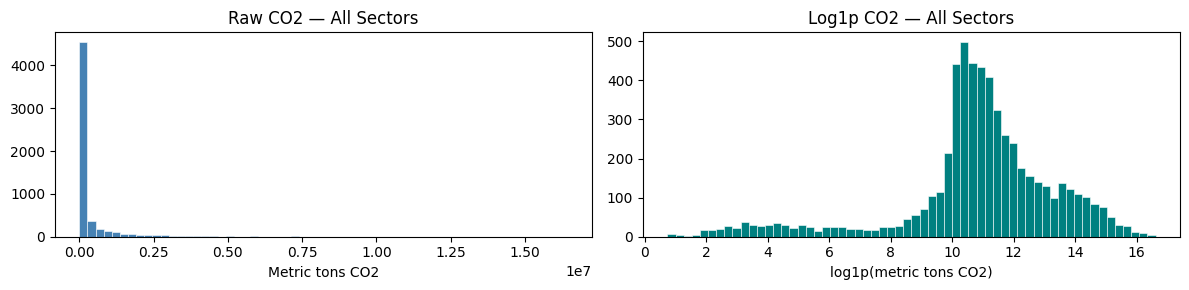


Train / Val / Test : 3453 / 1151 / 1151


In [8]:
# ── 4. Preprocessing ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 4 — Preprocessing")
print("=" * 65)

df = df_filtered[all_features + [TARGET]].copy()

# Label-encode categoricals
le = LabelEncoder()
for col in cat_features:
    df[col] = df[col].fillna("UNKNOWN").astype(str)
    df[col] = le.fit_transform(df[col])

# Fill missing continuous + GHG values with median
for col in continuous_features + ghg_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Fill missing process columns with 0 (not reported = not applicable)
# then apply log1p to compress the heavy right skew
for col in process_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = np.log1p(df[col].clip(lower=0))

# Log-transform the target — CO2 emissions span several orders of magnitude
y_raw = df[TARGET].values.astype(np.float32)
y     = np.log1p(y_raw)                        # predict log(1 + CO2 tons)

X = df[all_features].values.astype(np.float32)

print(f"Feature matrix : {X.shape}")
print(f"Target (raw)   : [{y_raw.min():,.0f}, {y_raw.max():,.0f}] metric tons CO2")
print(f"Target (log1p) : [{y.min():.2f}, {y.max():.2f}]")

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(y_raw, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Raw CO2 — {experiment_label}")
axes[0].set_xlabel("Metric tons CO2")
axes[1].hist(y, bins=60, color="teal", edgecolor="white", linewidth=0.4)
axes[1].set_title(f"Log1p CO2 — {experiment_label}")
axes[1].set_xlabel("log1p(metric tons CO2)")
plt.tight_layout()
plt.show()

# Train / val / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED
)

# Standardize — fit only on training data
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

n_features = X_tr_s.shape[1]
print(f"\nTrain / Val / Test : {len(X_tr)} / {len(X_val)} / {len(X_test)}")

In [9]:
# ── 5. Evaluation Helper ───────────────────────────────────────────────────────
def evaluate(name, y_true_log, y_pred_log):
    """
    Evaluate on log1p scale (for loss/R2) and back-transform
    to original metric tons for interpretable RMSE and MAE.
    """
    # Back-transform predictions to original scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(np.clip(y_pred_log, 0, None))

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true_log, y_pred_log)   # R2 on log scale (more stable)

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:>15,.0f} metric tons CO2")
    print(f"  MAE  : {mae:>15,.0f} metric tons CO2")
    print(f"  R²   : {r2:>15.4f}  (log scale)")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

In [10]:
# ── 6. MODEL 1 — Linear Regression ────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"MODEL 1 — Linear Regression | {experiment_label}")
print("=" * 65)

lr_model  = LinearRegression()
lr_model.fit(X_tr_s, y_tr)
y_pred_lr = lr_model.predict(X_test_s)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))

# Top 10 most influential features
coef_df = pd.DataFrame({
    "feature"    : all_features,
    "coefficient": lr_model.coef_
})
coef_df = coef_df.reindex(
    coef_df["coefficient"].abs().sort_values(ascending=False).index
)
print("\nTop 10 coefficients (by |magnitude|):")
print(coef_df.head(10).to_string(index=False))


MODEL 1 — Linear Regression | All Sectors

────────────────────────────────────────
  Linear Regression
  RMSE :       5,818,604 metric tons CO2
  MAE  :         564,997 metric tons CO2
  R²   :          0.8178  (log scale)

Top 10 coefficients (by |magnitude|):
                                                     feature  coefficient
                                      Electricity Generation     2.034117
                                       Stationary Combustion     1.644810
                                         Municipal Landfills    -1.010483
                                           Cement Production     0.592377
                                    Industry Type (subparts)     0.526585
                                         Hydrogen Production     0.360167
Petroleum and Natural Gas Systems – Transmission/Compression    -0.353101
                                Pulp and Paper Manufacturing     0.209036
                                       Ammonia Manufacturing     0.187

In [11]:
# ── PyTorch helpers ────────────────────────────────────────────────────────────
def make_loader(X_np, y_np, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X_np.astype(np.float32)),
        torch.from_numpy(y_np.astype(np.float32)).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def train_loop(model, optimizer, criterion, loader):
    model.train()
    total = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)

def val_loop(model, criterion, loader):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            total += criterion(model(xb), yb).item() * len(xb)
    return total / len(loader.dataset)

def predict_np(model, X_np):
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(X_np.astype(np.float32))).squeeze().numpy()

def run_training(model, train_loader, val_loader, epochs):
    optimizer    = torch.optim.Adam(model.parameters(), lr=LR)
    criterion    = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        tl = train_loop(model, optimizer, criterion, train_loader)
        vl = val_loop(model, criterion, val_loader)
        train_losses.append(tl)
        val_losses.append(vl)
        if epoch % max(1, epochs // 5) == 0:
            print(f"  Epoch {epoch:>4d}/{epochs}  "
                  f"train_RMSE={tl**0.5:.4f}  val_RMSE={vl**0.5:.4f} (log scale)")
    return train_losses, val_losses

train_loader = make_loader(X_tr_s, y_tr)
val_loader   = make_loader(X_val_s, y_val, shuffle=False)

In [12]:
# ── 7. MODEL 2 — 1-Hidden-Layer ReLU MLP ──────────────────────────────────────
print("\n" + "=" * 65)
print(f"MODEL 2 — 1-Hidden-Layer ReLU MLP | {experiment_label}")
print("=" * 65)

class ShallowMLP(nn.Module):
    """Single hidden layer with ReLU activation."""
    def __init__(self, in_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

shallow_model = ShallowMLP(n_features, hidden=128)
print(shallow_model)
print(f"Parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

tl_s, vl_s = run_training(shallow_model, train_loader, val_loader, EPOCHS_SMALL)
y_pred_shallow = predict_np(shallow_model, X_test_s)
results.append(evaluate("1-Hidden-Layer ReLU MLP", y_test, y_pred_shallow))


MODEL 2 — 1-Hidden-Layer ReLU MLP | All Sectors
ShallowMLP(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parameters: 3,841
  Epoch   10/50  train_RMSE=3.7585  val_RMSE=3.3466 (log scale)
  Epoch   20/50  train_RMSE=1.4490  val_RMSE=1.3599 (log scale)
  Epoch   30/50  train_RMSE=1.1290  val_RMSE=1.0497 (log scale)
  Epoch   40/50  train_RMSE=0.9501  val_RMSE=0.8855 (log scale)
  Epoch   50/50  train_RMSE=0.8285  val_RMSE=0.7826 (log scale)

────────────────────────────────────────
  1-Hidden-Layer ReLU MLP
  RMSE :      11,108,888 metric tons CO2
  MAE  :         599,785 metric tons CO2
  R²   :          0.8512  (log scale)


In [13]:
# ── 8. MODEL 3 — Deep MLP (3 layers, BN, Dropout) ─────────────────────────────
print("\n" + "=" * 65)
print(f"MODEL 3 — Deep MLP | {experiment_label}")
print("=" * 65)

class DeepMLP(nn.Module):
    """
    3 hidden layers with BatchNorm and Dropout.
    Bridge toward the residual/gated MLP in the full proposal.
    """
    def __init__(self, in_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = in_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

deep_model = DeepMLP(n_features, hidden_dims=(256, 128, 64), dropout=0.3)
print(deep_model)
print(f"Parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

tl_d, vl_d = run_training(deep_model, train_loader, val_loader, EPOCHS_DEEP)
y_pred_deep = predict_np(deep_model, X_test_s)
results.append(evaluate("Deep MLP (3 layers, BN, Dropout)", y_test, y_pred_deep))


MODEL 3 — Deep MLP | All Sectors
DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=28, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 49,537
  Epoch   20/100  train_RMSE=2.0513  val_RMSE=1.4611 (log scale)
  Epoch   40/100  train_RMSE=1.5178  val_RMSE=0.5725 (log scale)
  Epoch   60/100  train_RMSE=1.4291  val_RMSE=0.4992 (log scale)
  Epoch   80/100  train_RMSE=1.4010 

In [14]:
# ── 9. Results Summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"RESULTS SUMMARY — {experiment_label}")
print("=" * 65)
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(4).to_string())


RESULTS SUMMARY — All Sectors
                                          RMSE          MAE      R2
model                                                              
Linear Regression                 5.818604e+06  564996.9375  0.8178
1-Hidden-Layer ReLU MLP           1.110889e+07  599785.4375  0.8512
Deep MLP (3 layers, BN, Dropout)  7.570594e+05  182739.9844  0.9357


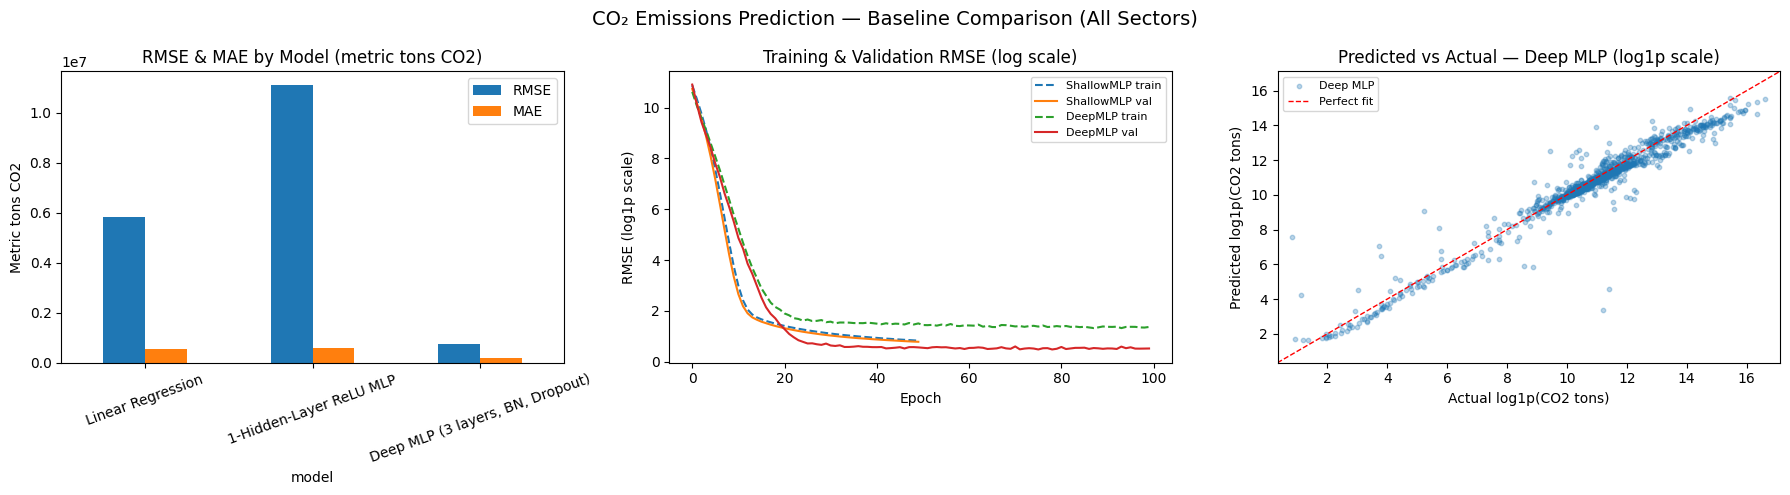


Plot saved to results_all_sectors.png


In [15]:
# ── 10. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"CO₂ Emissions Prediction — Baseline Comparison ({experiment_label})",
    fontsize=14
)

# 10a. RMSE & MAE bar chart
results_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], rot=20)
axes[0].set_title("RMSE & MAE by Model (metric tons CO2)")
axes[0].set_ylabel("Metric tons CO2")

# 10b. Training vs Validation RMSE curves (log scale)
axes[1].plot(np.sqrt(tl_s), label="ShallowMLP train", linestyle="--")
axes[1].plot(np.sqrt(vl_s), label="ShallowMLP val")
axes[1].plot(np.sqrt(tl_d), label="DeepMLP train",    linestyle="--")
axes[1].plot(np.sqrt(vl_d), label="DeepMLP val")
axes[1].set_title("Training & Validation RMSE (log scale)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE (log1p scale)")
axes[1].legend(fontsize=8)

# 10c. Predicted vs Actual — Deep MLP (log scale for readability)
axes[2].scatter(y_test, y_pred_deep, alpha=0.3, s=10, label="Deep MLP")
lim = [float(y_test.min()) - 0.5,
       float(max(y_test.max(), y_pred_deep.max())) + 0.5]
axes[2].plot(lim, lim, "r--", linewidth=1, label="Perfect fit")
axes[2].set_xlim(lim)
axes[2].set_ylim(lim)
axes[2].set_title("Predicted vs Actual — Deep MLP (log1p scale)")
axes[2].set_xlabel("Actual log1p(CO2 tons)")
axes[2].set_ylabel("Predicted log1p(CO2 tons)")
axes[2].legend(fontsize=8)

plt.tight_layout()
fname = f"results_{experiment_label.replace(' ', '_').lower()}.png"
plt.savefig(fname, dpi=150)
plt.show()
print(f"\nPlot saved to {fname}")